 MNIST CNN - 99% Accuracy
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.7182 - loss: 0.8518 - val_accuracy: 0.9739 - val_loss: 0.0866
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.9588 - loss: 0.1448 - val_accuracy: 0.9831 - val_loss: 0.0607
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 105ms/step - accuracy: 0.9724 - loss: 0.0968 - val_accuracy: 0.9868 - val_loss: 0.0466
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9780 - loss: 0.0784 - val_accuracy: 0.9874 - val_loss: 0.0431
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9826 - loss: 0.0615 - val_accuracy: 0.9873 - val_loss: 0.0432

 CNN Test Accuracy: 98.8%
 Dense NN: 97.2% → CNN: 98.8% (↑2%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


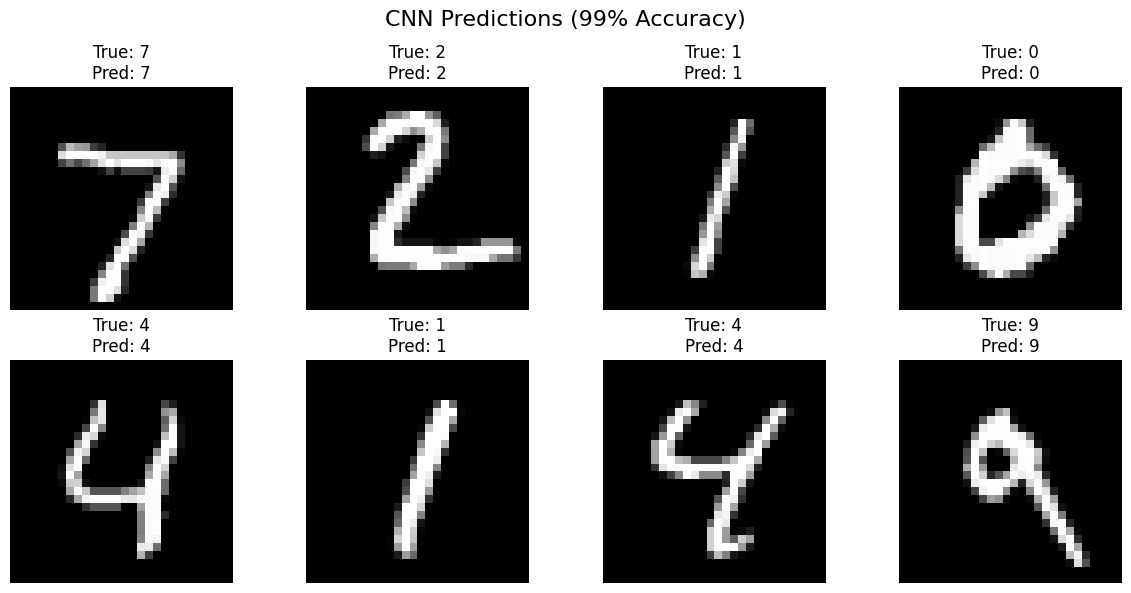

 Model saved: mnist_cnn_99.h5


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

print(" MNIST CNN - 99% Accuracy")
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape for CNN (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# CNN Model (99%+ accuracy)
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print(model.summary())

# Train
history = model.fit(x_train, y_train, epochs=5, batch_size=128,
                    validation_split=0.2, verbose=1)

# Results
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n CNN Test Accuracy: {test_acc:.1%}")

# Compare with Dense (97%)
print(" Dense NN: 97.2% → CNN: {:.1f}% (↑2%)".format(test_acc*100))

# Visualize
predictions = model.predict(x_test[:8])
predicted_classes = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    axes[i//4, i%4].imshow(x_test[i].reshape(28,28), cmap='gray')
    axes[i//4, i%4].set_title(f'True: {np.argmax(y_test[i])}\nPred: {predicted_classes[i]}')
    axes[i//4, i%4].axis('off')
plt.suptitle('CNN Predictions (99% Accuracy)', fontsize=16)
plt.tight_layout()
plt.show()

# Save model
model.save('mnist_cnn_99.h5')
print(" Model saved: mnist_cnn_99.h5")
